In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Reading CSV

In [3]:
df =  pd.read_csv("price.csv")
df

,Airline,Airline_encoded,Source,Source_encoded,Destination,Destination_encoded,Date,Month,Year,Hour,Minute,Price
0,IndiGo,3,Banglore,0,Delhi,2,24,3,2019,22,20,3897
1,Air India,1,Kolkata,3,Banglore,0,1,5,2019,5,50,7662
2,Jet Airways,4,Delhi,2,Cochin,1,9,6,2019,9,25,13882
3,IndiGo,3,Kolkata,3,Banglore,0,12,5,2019,18,5,6218
4,IndiGo,3,Banglore,0,Delhi,2,1,3,2019,16,50,13302
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,0,Kolkata,3,Banglore,0,9,4,2019,19,55,4107
10679,Air India,1,Kolkata,3,Banglore,0,27,4,2019,20,45,4145
10680,Jet Airways,4,Banglore,0,Delhi,2,27,4,2019,8,20,7229
10681,Vistara,10,Banglore,0,Delhi,2,1,3,2019,11,30,12648


In [4]:
#Checking NULL
df.isnull().sum()

Airline                0
Airline_encoded        0
Source                 0
Source_encoded         0
Destination            0
Destination_encoded    0
Date                   0
Month                  0
Year                   0
Hour                   0
Minute                 0
Price                  0
dtype: int64

In [5]:
#Checking the INFORMATION to know the data type count of null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Airline              10683 non-null  object
 1   Airline_encoded      10683 non-null  int64 
 2   Source               10683 non-null  object
 3   Source_encoded       10683 non-null  int64 
 4   Destination          10683 non-null  object
 5   Destination_encoded  10683 non-null  int64 
 6   Date                 10683 non-null  int64 
 7   Month                10683 non-null  int64 
 8   Year                 10683 non-null  int64 
 9   Hour                 10683 non-null  int64 
 10  Minute               10683 non-null  int64 
 11  Price                10683 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 1001.7+ KB


In [6]:
#DESCRIPTION of data to know its statistical value
df.describe()

,Airline_encoded,Source_encoded,Destination_encoded,Date,Month,Year,Hour,Minute,Price
count,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.0,10683.000000,10683.000000,10683.000000
mean,3.965927,1.952261,1.174389,13.508378,4.708602,2019.0,12.490686,24.411214,9087.064121
std,2.352155,1.177221,1.012934,8.479277,1.164357,0.0,5.748650,18.767980,4611.359167
min,0.000000,0.000000,0.000000,1.000000,3.000000,2019.0,0.000000,0.000000,1759.000000
25%,3.000000,2.000000,0.000000,6.000000,3.000000,2019.0,8.000000,5.000000,5277.000000
50%,4.000000,2.000000,1.000000,12.000000,5.000000,2019.0,11.000000,25.000000,8372.000000
75%,4.000000,3.000000,2.000000,21.000000,6.000000,2019.0,18.000000,40.000000,12373.000000
max,11.000000,4.000000,4.000000,27.000000,6.000000,2019.0,23.000000,55.000000,79512.000000


In [7]:
#These is done to know which unnecessary columns need to be dropped
df.columns

Index(['Airline', 'Airline_encoded', 'Source', 'Source_encoded', 'Destination',
       'Destination_encoded', 'Date', 'Month', 'Year', 'Hour', 'Minute',
       'Price'],
      dtype='object')

In [8]:
#These is done to convert to datetime format,dropping the old columns and changing the name to journey_day,journey_month 
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df['Journey_Day'] = df['Date'].dt.day
df['Journey_Month'] = df['Date'].dt.month
df.drop(['Date', 'Month', 'Year'], axis=1, inplace=True)

In [9]:
df.columns

Index(['Airline', 'Airline_encoded', 'Source', 'Source_encoded', 'Destination',
       'Destination_encoded', 'Hour', 'Minute', 'Price', 'Journey_Day',
       'Journey_Month'],
      dtype='object')

In [10]:
#statistical calculation is done
#Skewness > 0 positive, < 0 Negative, = 0 Normal Skewed

print("Mean of price is :",df[('Price')].mean())

print("Median of price is:",df[('Price')].median())

print("Minimum value of price is:",df[('Price')].min())

print("Maximum value of price is:",df[('Price')].max())

print("Skewness of price:",df[('Price')].skew())

Mean of price is : 9087.064120565385
Median of price is: 8372.0
Minimum value of price is: 1759
Maximum value of price is: 79512
Skewness of price: 1.8125523782189141


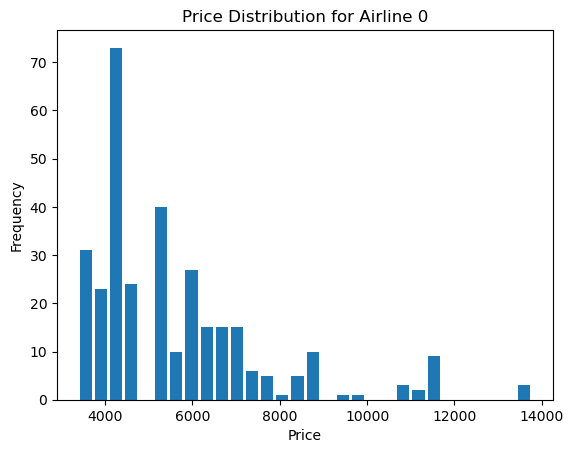

In [11]:
#HISTOGRAM CHART 
#It is done to analyze the price of airlines with further segmenting the price with the Airlines
plt.hist(df[df['Airline_encoded']==0]['Price'], bins=30,rwidth=0.8)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution for Airline 0')
plt.show()

In [12]:
#REquired to do as Machine Learning takes only numeric values
df.drop(['Airline', 'Source', 'Destination'], axis=1, inplace=True, errors='ignore')

In [13]:
#Feature selection
x = df.drop('Price',axis=1)
y = df['Price']

In [14]:
#Train Test split in 80-20 method
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 ,random_state=42)
                                         

In [15]:
#Model Selection and Training

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators = 200,
    random_state=42
)
rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [18]:
#Model Evaluation

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

def evaluate_model(model,x_test,y_test):
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,y_pred)
    return mae,mse,rmse,r2

In [19]:
lr_metrics = evaluate_model(lr, x_test, y_test)
dt_metrics = evaluate_model(dt, x_test, y_test)
rf_metrics = evaluate_model(rf, x_test, y_test)

In [20]:
#comparision Table
import pandas as pd

model_comparison = pd.DataFrame({
    'Model' : ['LinearRegression','Decision Tree','Random Forest'],
    'MAE' : [lr_metrics[0],dt_metrics[0],rf_metrics[0]],
    'MSE' : [lr_metrics[1],dt_metrics[1],rf_metrics[1]],
    'RMSE' : [lr_metrics[2],dt_metrics[2],rf_metrics[2]],
    'R2 Score' : [lr_metrics[3],dt_metrics[3],rf_metrics[3]]
}) 

model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,LinearRegression,3402.312972,1.967847e+07,4436.041918,0.070190
1,Decision Tree,1758.510311,7.816437e+06,2795.789245,0.630672
2,Random Forest,1761.704645,7.839984e+06,2799.997227,0.629560


In [46]:
#Final Model

final_model = rf

sample = pd.DataFrame([{
    'Airline_encoded' : 2,
    'Source_encoded' : 1,
    'Destination_encoded' : 3,
    'Hour' : 10,
    'Minute' : 30,
    'Journey_Day' : 15,
    'Journey_Month' : 6
}])

Predicted = final_model.predict(sample)
Predicted

array([7043.93501942])